In [291]:
import subprocess
import pandas as pd
import matplotlib.pyplot as plt
import glob
import math
import os
import seaborn as sns
import numpy as np

In [292]:
import subprocess

r_script = """
data <- readRDS('/Users/cherylxiang/Documents/GitHub/demultiplexing-methods/brian-scripts/call_types.rds')
write.csv(data, 'temp_output.csv')
"""

with open('temp_convert.R', 'w') as f:
    f.write(r_script)

subprocess.run(['Rscript', 'temp_convert.R'], check=True)

import pandas as pd
brian_calls = pd.read_csv('temp_output.csv', index_col=0)
brian_calls.head()

'getOption("repos")' replaces Bioconductor standard repositories, see
'help("repositories", package = "BiocManager")' for details.
Replacement repositories:
    BioCsoft: https://bioconductor.org/packages/3.22/bioc
    BioCann: https://bioconductor.org/packages/3.22/data/annotation
    BioCexp: https://bioconductor.org/packages/3.22/data/experiment
    BioCworkflows: https://bioconductor.org/packages/3.22/workflows
    BioCbooks: https://bioconductor.org/packages/3.22/books
    CRAN: https://cloud.r-project.org


,Object,Dataset,Method,Singlet,Multiplet,Negative
1,labels_bar11_beacon,bar11,beacon,5125,252,344
2,labels_bar11_bff_cluster,bar11,bff_cluster,4643,1065,14
3,labels_bar11_bff_raw,bar11,bff_raw,3176,2532,14
4,labels_bar11_cmd,bar11,cmd,5513,206,2
5,labels_bar11_demuxem,bar11,demuxem,3878,1599,246


In [293]:
#temporarily drop beacon and cmd rows
brian_calls = brian_calls[~brian_calls['Method'].isin(['cmd', 'beacon'])]

In [294]:
brian_calls['Dataset'].unique()

array(['bar11', 'cook_mix1', 'cook_mix2', 'cook_mix3a', 'cook_mix3b',
       'cook_mix4a', 'cook_mix4b', 'gaublomme', 'howitt_batch1_c1',
       'howitt_batch1_c2', 'howitt_batch2_c1', 'howitt_batch2_c2',
       'howitt_batch3_c1', 'howitt_batch3_c2', 'howitt_capture1',
       'howitt_capture2', 'howitt_capture3', 'mcginnis_ab', 'mcginnis_ms'],
      dtype=object)

In [295]:
datasets = [
    'bar11',
    'gaublomme',
    'mcginnis_hto',
    'mcginnis_ms',
    'cook_mix1',
    'cook_mix2',
    'cook_mix3a',
    'cook_mix3b',
    'cook_mix4a',
    'cook_mix4b',
    'howitt_cell_cap1',
    'howitt_cell_cap2',
    'howitt_cell_cap3',
    'howitt_b1c1',
    'howitt_b1c2',
    'howitt_b2c1',
    'howitt_b2c2',
    'howitt_b3c1',
    'howitt_b3c2',
]

dataset_labels = {
    'bar11' : 'bar11',
    'gaublomme': 'gaublomme',
    'mcginnis_hto': 'mcginnis_ab',
    'mcginnis_ms': 'mcginnis_ms',
    'cook_mix1' : 'cook_mix1',
    'cook_mix2' : 'cook_mix2',
    'cook_mix3a' : 'cook_mix3a',
    'cook_mix3b' : 'cook_mix3b',
    'cook_mix4a' : 'cook_mix4a',
    'cook_mix4b' : 'cook_mix4b',
    'howitt_cell_cap1' : 'howitt_capture1',
    'howitt_cell_cap2' : 'howitt_capture2',
    'howitt_cell_cap3' : 'howitt_capture3',
    'howitt_b1c1' : 'howitt_batch1_c1',
    'howitt_b1c2' : 'howitt_batch1_c2',
    'howitt_b2c1' : 'howitt_batch2_c1',
    'howitt_b2c2' : 'howitt_batch2_c2',
    'howitt_b3c1' : 'howitt_batch3_c1',
    'howitt_b3c2' : 'howitt_batch3_c2',
}

In [296]:
brian_calls['Method'].unique()

array(['bff_cluster', 'bff_raw', 'demuxem', 'demuxmix', 'demuxmix_naive',
       'dm', 'dm2', 'gmm', 'hashed', 'hsolo', 'hto'], dtype=object)

In [297]:
methods = [
    'demultiplex',
    'demultiplex2',
    'gmmdemux',
    'htodemux',
    'hashsolo',
    'hasheddrops',
    'bffraw',
    'bffcluster',
    'demuxmix',
    'demuxmixnaive',
    'demuxem'
]

method_labels = {
    'demultiplex': 'dm',
    'demultiplex2': 'dm2',
    'htodemux': 'hto',
    'hashsolo': 'hsolo',
    'hasheddrops': 'hashed',
    'bffraw': 'bff_raw',
    'bffcluster': 'bff_cluster',
    'gmmdemux': 'gmm',
    'demuxmix': 'demuxmix',
    'demuxmixnaive': 'demuxmix_naive',
    'cmddemux': 'cmd',
    'demuxem' : 'demuxem'
}

In [298]:
#get cheryl's calls
base_dir = '/Users/cherylxiang/Documents/GitHub/demultiplexing-methods'

rows = []
for dataset in datasets:
    for method in methods:
        summary_file = f'{base_dir}/results/{method}/{dataset}/summary.csv'
        if not os.path.exists(summary_file):
            continue
        summary = pd.read_csv(summary_file)
        summary = summary[summary['classification'] != 'total']
        
        row = {
            'Dataset': dataset,
            'Method': method,
            'Singlet': summary.loc[summary['classification'] == 'singlet', 'n'].values[0] if 'singlet' in summary['classification'].values else 0,
            'Doublet': summary.loc[summary['classification'] == 'doublet', 'n'].values[0] if 'doublet' in summary['classification'].values else 0,
            'Negative': summary.loc[summary['classification'] == 'negative', 'n'].values[0] if 'negative' in summary['classification'].values else 0,
        }
        rows.append(row)

cher_calls = pd.DataFrame(rows)
cher_calls['Object'] = 'labels_' + cher_calls['Dataset'] + '_' + cher_calls['Method']
cher_calls = cher_calls[['Object', 'Dataset', 'Method', 'Singlet', 'Doublet', 'Negative']]
cher_calls = cher_calls.reset_index(drop=True)
cher_calls.index += 1
cher_calls['Dataset'] = cher_calls['Dataset'].map(lambda x: dataset_labels.get(x, x))
cher_calls['Method'] = cher_calls['Method'].map(lambda x: method_labels.get(x, x))
cher_calls['Object'] = 'labels_' + cher_calls['Dataset'] + '_' + cher_calls['Method']
cher_calls.rename(columns={'Doublet': 'Multiplet'}, inplace=True)
cher_calls.head()

,Object,Dataset,Method,Singlet,Multiplet,Negative
1,labels_bar11_dm,bar11,dm,3350,346,2026
2,labels_bar11_dm2,bar11,dm2,3760,360,1601
3,labels_bar11_gmm,bar11,gmm,2671,202,2849
4,labels_bar11_hto,bar11,hto,3155,1041,1526
5,labels_bar11_hsolo,bar11,hsolo,5261,457,4


In [299]:
#what is happening
print(cher_calls.shape)
print(brian_calls.shape)

(157, 6)
(183, 6)


In [300]:
#need to double check but i think these are just all the ones that did not run (I will add mine back as negatives)
brian_keys = set(zip(brian_calls['Dataset'], brian_calls['Method']))
cher_keys = set(zip(cher_calls['Dataset'], cher_calls['Method']))

missing = brian_keys - cher_keys

for k in sorted(missing):
    print(k)

('cook_mix1', 'demuxmix')
('cook_mix1', 'demuxmix_naive')
('cook_mix1', 'gmm')
('cook_mix1', 'hto')
('cook_mix2', 'demuxmix')
('cook_mix2', 'demuxmix_naive')
('cook_mix2', 'gmm')
('cook_mix2', 'hto')
('cook_mix3a', 'demuxmix')
('cook_mix3a', 'demuxmix_naive')
('cook_mix3a', 'gmm')
('cook_mix3a', 'hto')
('cook_mix3b', 'demuxmix')
('cook_mix3b', 'demuxmix_naive')
('cook_mix3b', 'gmm')
('cook_mix3b', 'hto')
('cook_mix4a', 'demuxmix')
('cook_mix4a', 'demuxmix_naive')
('cook_mix4a', 'dm2')
('cook_mix4a', 'gmm')
('cook_mix4a', 'hto')
('cook_mix4b', 'demuxmix')
('cook_mix4b', 'demuxmix_naive')
('cook_mix4b', 'gmm')
('cook_mix4b', 'hto')
('gaublomme', 'demuxem')


In [301]:
print(sorted(brian_calls['Dataset'].unique()))
print(sorted(cher_calls['Dataset'].unique()))

['bar11', 'cook_mix1', 'cook_mix2', 'cook_mix3a', 'cook_mix3b', 'cook_mix4a', 'cook_mix4b', 'gaublomme', 'howitt_batch1_c1', 'howitt_batch1_c2', 'howitt_batch2_c1', 'howitt_batch2_c2', 'howitt_batch3_c1', 'howitt_batch3_c2', 'howitt_capture1', 'howitt_capture2', 'howitt_capture3', 'mcginnis_ab', 'mcginnis_ms']
['bar11', 'cook_mix1', 'cook_mix2', 'cook_mix3a', 'cook_mix3b', 'cook_mix4a', 'cook_mix4b', 'gaublomme', 'howitt_batch1_c1', 'howitt_batch1_c2', 'howitt_batch2_c1', 'howitt_batch2_c2', 'howitt_batch3_c1', 'howitt_batch3_c2', 'howitt_capture1', 'howitt_capture2', 'howitt_capture3', 'mcginnis_ab', 'mcginnis_ms']


In [302]:
print(sorted(brian_calls['Method'].unique()))
print(sorted(cher_calls['Method'].unique()))

['bff_cluster', 'bff_raw', 'demuxem', 'demuxmix', 'demuxmix_naive', 'dm', 'dm2', 'gmm', 'hashed', 'hsolo', 'hto']
['bff_cluster', 'bff_raw', 'demuxem', 'demuxmix', 'demuxmix_naive', 'dm', 'dm2', 'gmm', 'hashed', 'hsolo', 'hto']


In [303]:
merged = brian_calls.merge(
    cher_calls,
    on=['Dataset', 'Method'],
    suffixes=('_brian', '_cher')
)

discrepancies = merged[
    (merged['Singlet_brian'] != merged['Singlet_cher']) |
    (merged['Multiplet_brian'] != merged['Multiplet_cher']) |
    (merged['Negative_brian'] != merged['Negative_cher'])
].copy()

discrepancies = discrepancies.drop(columns=['Object_cher', 'Object_brian'])
discrepancies

,Dataset,Method,Singlet_brian,Multiplet_brian,Negative_brian,Singlet_cher,Multiplet_cher,Negative_cher
2,bar11,demuxem,3878,1599,246,3846,1642,235
7,bar11,gmm,2373,237,3112,2671,202,2849
14,cook_mix1,dm2,3576,8777,304,3574,8782,301
19,cook_mix2,dm,4045,1100,7444,4367,1398,6824
20,cook_mix2,dm2,4499,7958,132,4514,7943,132
26,cook_mix3a,dm2,7842,5221,255,7841,5224,253
31,cook_mix3b,dm,7991,2036,1357,8524,2036,824
32,cook_mix3b,dm2,6090,5164,130,6089,5165,130
43,cook_mix4b,dm2,8355,6388,177,8352,6387,181
64,howitt_batch1_c1,hto,9182,1858,539,9153,1986,440


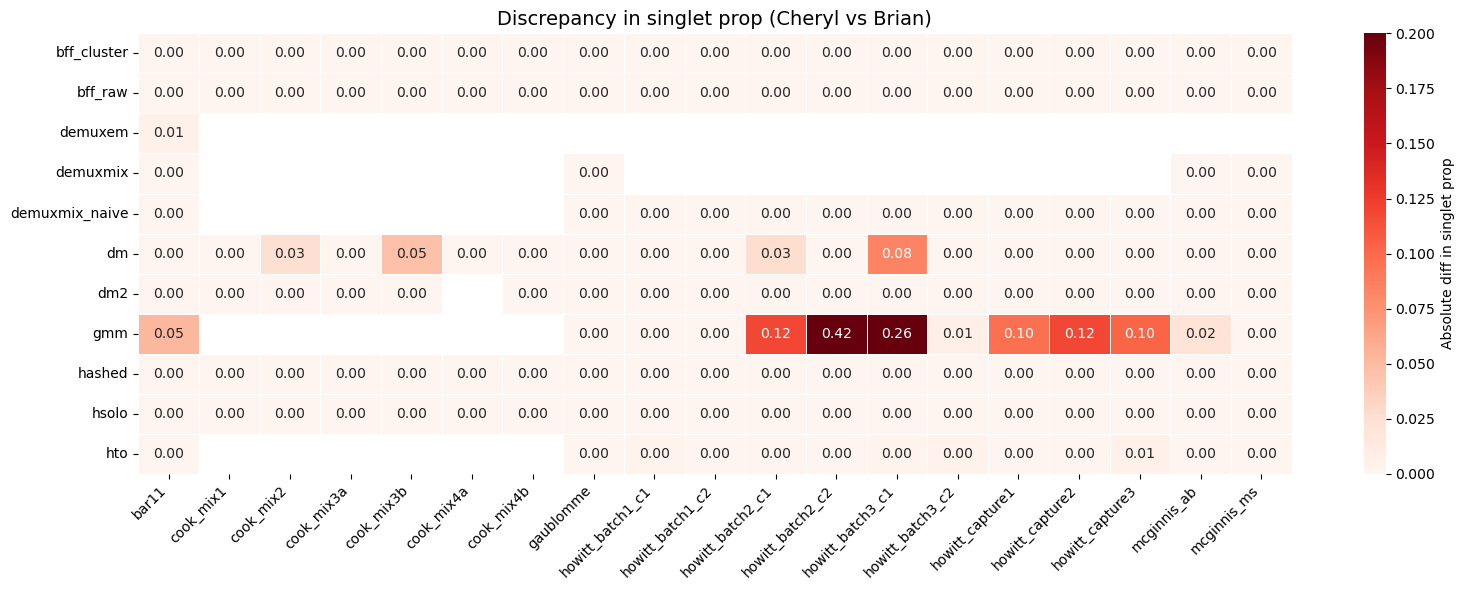

In [310]:
#singlet prop difference
merged['singlet_prop_brian'] = merged['Singlet_brian'] / (merged['Singlet_brian'] + merged['Multiplet_brian'] + merged['Negative_brian'])
merged['singlet_prop_cher'] = merged['Singlet_cher'] / (merged['Singlet_cher'] + merged['Multiplet_cher'] + merged['Negative_cher'])
merged['singlet_diff'] = (merged['singlet_prop_cher'] - merged['singlet_prop_brian']).abs()

heatmap_data = merged.pivot_table(
    index='Method',
    columns='Dataset',
    values='singlet_diff',
    fill_value=np.nan
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='Reds',
    vmin=0,
    vmax=0.2,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Absolute diff in singlet prop'}
)

ax.set_title('Discrepancy in singlet prop (Cheryl vs Brian)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
#plt.savefig('analysis/figures/discrepancy_heatmap.pdf')
plt.show()

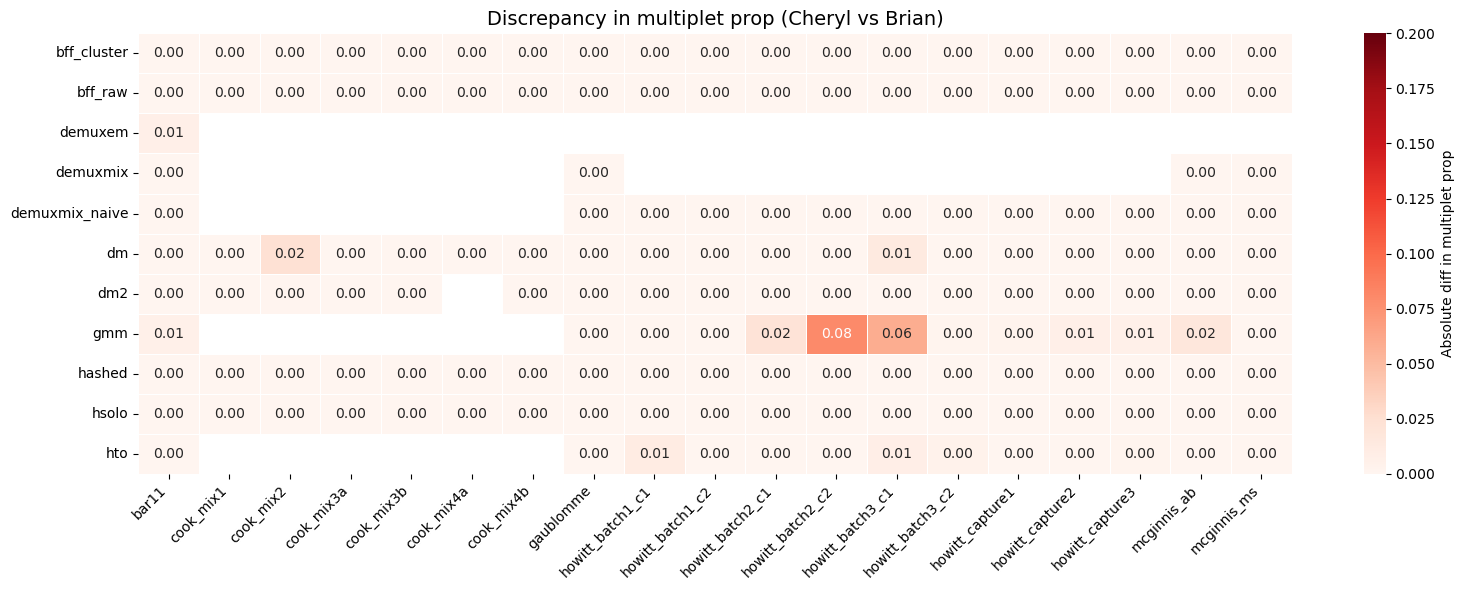

In [305]:
#multiplet prop difference
merged['multiplet_prop_brian'] = merged['Multiplet_brian'] / (merged['Singlet_brian'] + merged['Multiplet_brian'] + merged['Negative_brian'])
merged['multiplet_prop_cher'] = merged['Multiplet_cher'] / (merged['Singlet_cher'] + merged['Multiplet_cher'] + merged['Negative_cher'])
merged['multiplet_diff'] = (merged['multiplet_prop_cher'] - merged['multiplet_prop_brian']).abs()

heatmap_data = merged.pivot_table(
    index='Method',
    columns='Dataset',
    values='multiplet_diff',
    fill_value=np.nan
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='Reds',
    vmin=0,
    vmax=0.2,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Absolute diff in multiplet prop'}
)

ax.set_title('Discrepancy in multiplet prop (Cheryl vs Brian)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
#plt.savefig('analysis/figures/discrepancy_heatmap.pdf')
plt.show()

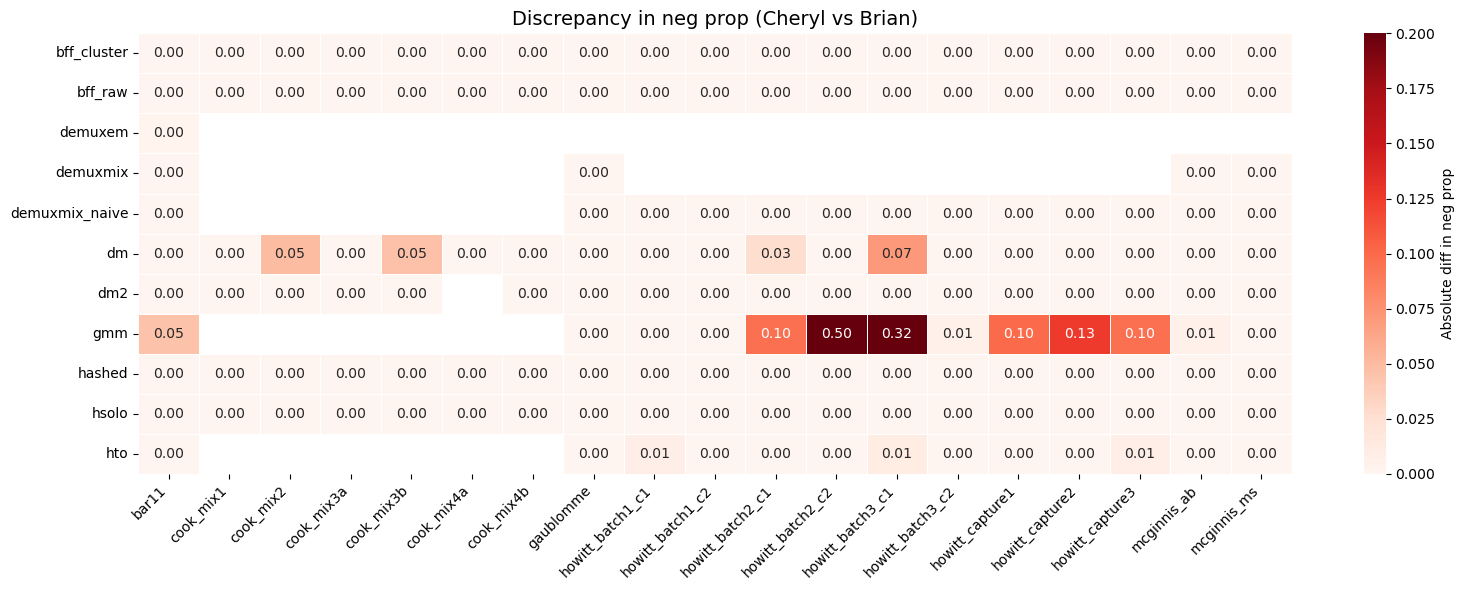

In [306]:
#neg prop difference
merged['neg_prop_brian'] = merged['Negative_brian'] / (merged['Singlet_brian'] + merged['Multiplet_brian'] + merged['Negative_brian'])
merged['neg_prop_cher'] = merged['Negative_cher'] / (merged['Singlet_cher'] + merged['Multiplet_cher'] + merged['Negative_cher'])
merged['neg_diff'] = (merged['neg_prop_cher'] - merged['neg_prop_brian']).abs()

heatmap_data = merged.pivot_table(
    index='Method',
    columns='Dataset',
    values='neg_diff',
    fill_value=np.nan
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='Reds',
    vmin=0,
    vmax=0.2,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Absolute diff in neg prop'}
)

ax.set_title('Discrepancy in neg prop (Cheryl vs Brian)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
#plt.savefig('analysis/figures/discrepancy_heatmap.pdf')
plt.show()

In [307]:
merged['singlet_diff'] = (merged['Singlet_cher'] - merged['Singlet_brian']).abs()
merged['multiplet_diff'] = (merged['Multiplet_cher'] - merged['Multiplet_brian']).abs()
merged['negative_diff'] = (merged['Negative_cher'] - merged['Negative_brian']).abs()

# pivot to matrix using singlet diff (or swap for doublet/negative)
heatmap_data = merged.pivot_table(
    index='Method',
    columns='Dataset',
    values='singlet_diff',
    fill_value=np.nan
)

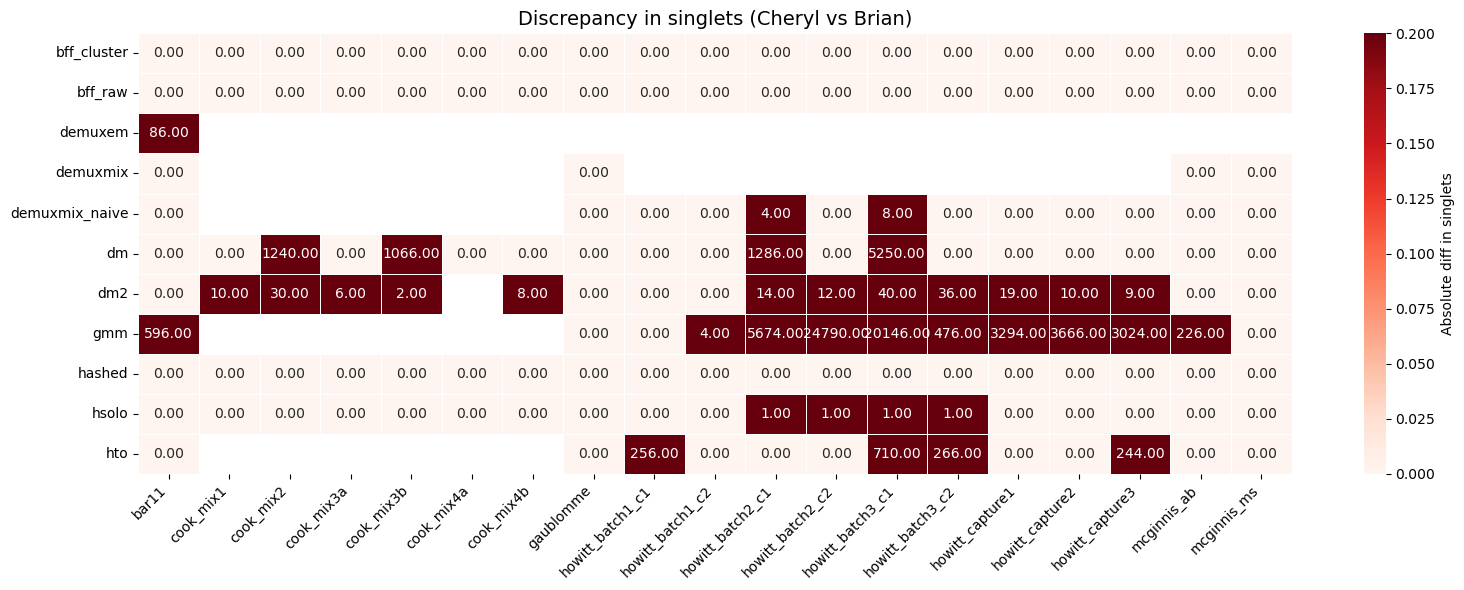

In [309]:
merged['total_diff'] = merged['singlet_diff'] + merged['multiplet_diff'] + merged['negative_diff']

heatmap_data = merged.pivot_table(
    index='Method',
    columns='Dataset',
    values='total_diff',
    fill_value=np.nan
)

fig, ax = plt.subplots(figsize=(16, 6))
sns.heatmap(
    heatmap_data,
    ax=ax,
    cmap='Reds',
    vmin=0,
    vmax=0.2,
    annot=True,
    fmt='.2f',
    linewidths=0.5,
    cbar_kws={'label': 'Absolute diff in singlets'}
)

ax.set_title('Discrepancy in singlets (Cheryl vs Brian)', fontsize=14)
ax.set_xlabel('')
ax.set_ylabel('')
plt.xticks(rotation=45, ha='right', fontsize=10)
plt.yticks(fontsize=10)
plt.tight_layout()
#plt.savefig('analysis/figures/discrepancy_heatmap.pdf')
plt.show()